In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../dataset/intern_data_cleaned.csv")
df.head()

,Intern_ID,Name,Department,Tasks_Assigned,Tasks_Completed,Hours_Worked,Attendance,Performance_Score,Completion_Rate
0,1,Meena,Marketing,19,8,174,93,92,42.105263
1,2,Sneha,HR,11,6,133,88,86,54.545455
2,3,Arjun,HR,5,13,137,97,61,100.000000
3,4,Meena,Finance,8,19,146,95,52,100.000000
4,5,Rahul,HR,17,8,183,92,50,47.058824


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Intern_ID          100 non-null    int64  
 1   Name               100 non-null    str    
 2   Department         100 non-null    str    
 3   Tasks_Assigned     100 non-null    int64  
 4   Tasks_Completed    100 non-null    int64  
 5   Hours_Worked       100 non-null    int64  
 6   Attendance         100 non-null    int64  
 7   Performance_Score  100 non-null    int64  
 8   Completion_Rate    100 non-null    float64
dtypes: float64(1), int64(6), str(2)
memory usage: 8.2 KB


,Intern_ID,Tasks_Assigned,Tasks_Completed,Hours_Worked,Attendance,Performance_Score,Completion_Rate
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,11.830000,10.110000,137.700000,85.890000,75.940000,72.450610
std,29.011492,4.481285,5.489926,34.429404,9.480331,13.764851,28.028544
min,1.000000,5.000000,3.000000,81.000000,70.000000,50.000000,15.789474
25%,25.750000,8.000000,5.000000,105.750000,76.750000,63.000000,50.000000
50%,50.500000,12.000000,9.000000,135.000000,88.000000,75.000000,77.350427
75%,75.250000,16.000000,16.000000,171.250000,95.000000,86.000000,100.000000
max,100.000000,19.000000,19.000000,198.000000,99.000000,99.000000,100.000000


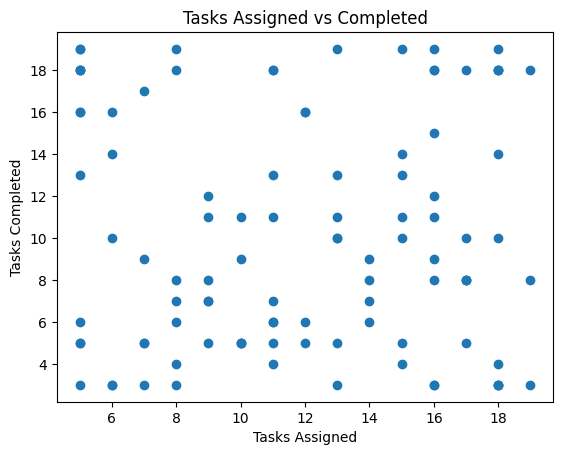

In [4]:
plt.scatter(df["Tasks_Assigned"], df["Tasks_Completed"])
plt.xlabel("Tasks Assigned")
plt.ylabel("Tasks Completed")
plt.title("Tasks Assigned vs Completed")
plt.show()

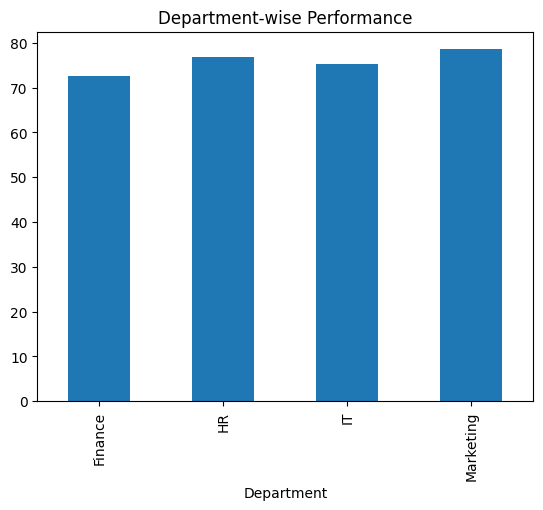

In [5]:
df.groupby("Department")["Performance_Score"].mean().plot(kind="bar")
plt.title("Department-wise Performance")
plt.show()

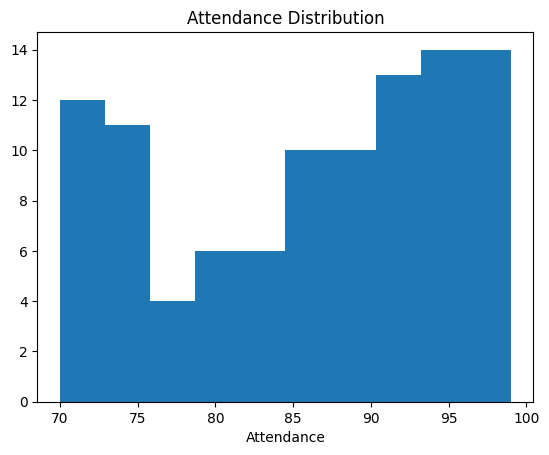

In [6]:
plt.hist(df["Attendance"])
plt.title("Attendance Distribution")
plt.xlabel("Attendance")
plt.show()

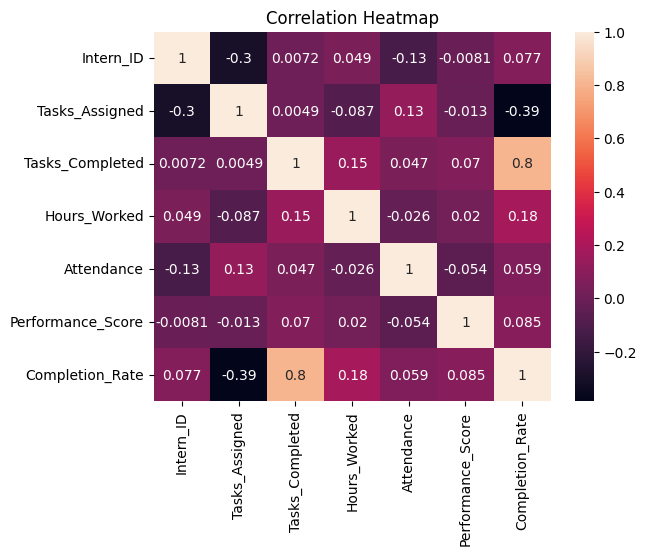

In [7]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

INSIGHTS

Performance varies among interns
Attendance impacts performance
Some departments perform better
Completion rate is important

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("../Dataset/intern_data_cleaned.csv")
df.head()

,Intern_ID,Name,Department,Tasks_Assigned,Tasks_Completed,Hours_Worked,Attendance,Performance_Score,Completion_Rate
0,1,Meena,Marketing,19,8,174,93,92,42.105263
1,2,Sneha,HR,11,6,133,88,86,54.545455
2,3,Arjun,HR,5,13,137,97,61,100.000000
3,4,Meena,Finance,8,19,146,95,52,100.000000
4,5,Rahul,HR,17,8,183,92,50,47.058824


In [3]:
dept_perf = df.groupby("Department")["Performance_Score"].mean()
print(dept_perf)

Department
Finance      72.541667
HR           76.850000
IT           75.346154
Marketing    78.566667
Name: Performance_Score, dtype: float64


In [4]:
df.groupby("Attendance")["Performance_Score"].mean()

Attendance
70    78.142857
71    70.666667
72    82.500000
73    85.333333
74    75.875000
76    91.500000
77    59.000000
78    62.000000
79    80.500000
81    76.250000
82    77.500000
83    82.500000
84    69.500000
85    68.000000
86    86.000000
87    94.000000
88    77.666667
89    68.333333
90    82.250000
91    63.000000
92    78.800000
93    74.750000
94    79.500000
95    71.636364
96    85.000000
97    79.000000
98    70.750000
99    82.166667
Name: Performance_Score, dtype: float64

In [5]:
df["Attendance_Level"] = pd.cut(
    df["Attendance"],
    bins=[0, 50, 75, 100],
    labels=["Low", "Medium", "High"]
)

df.groupby("Attendance_Level")["Performance_Score"].mean()

Attendance_Level
Medium    77.695652
High      75.415584
Name: Performance_Score, dtype: float64

In [7]:
df["Completion_Rate"] = (df["Tasks_Completed"] / df["Tasks_Assigned"]) * 100
df["Completion_Rate"].describe()

count    100.000000
mean     104.113414
std       87.389911
min       15.789474
25%       50.000000
50%       77.350427
75%      118.323864
max      380.000000
Name: Completion_Rate, dtype: float64

In [8]:
df.groupby("Department")["Completion_Rate"].mean()

Department
Finance      107.016844
HR           104.913413
IT            81.783617
Marketing    120.609829
Name: Completion_Rate, dtype: float64

In [9]:
top10 = df.sort_values(by="Performance_Score", ascending=False).head(10)
top10

,Intern_ID,Name,Department,Tasks_Assigned,Tasks_Completed,Hours_Worked,Attendance,Performance_Score,Completion_Rate
30,31,Arjun,Finance,16,18,129,76,99,112.500000
16,17,Sneha,IT,11,6,169,95,99,54.545455
48,49,Kiran,IT,8,6,94,86,98,75.000000
43,44,Vikram,Finance,5,5,95,98,98,100.000000
56,57,Vikram,Marketing,13,5,130,95,98,38.461538
64,65,Meena,HR,19,18,165,99,98,94.736842
71,72,Diya,IT,18,14,186,73,98,77.777778
45,46,Sneha,Marketing,15,13,155,97,97,86.666667
66,67,Sneha,Finance,10,9,131,92,97,90.000000
83,84,Vikram,Marketing,12,6,85,85,96,50.000000


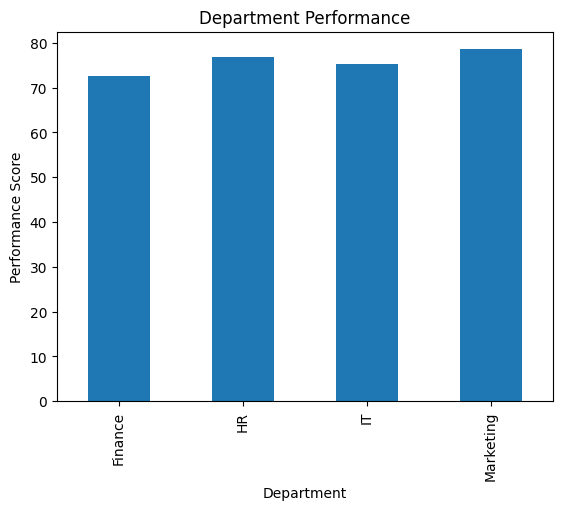

In [10]:
dept_perf.plot(kind="bar")
plt.title("Department Performance")
plt.xlabel("Department")
plt.ylabel("Performance Score")
plt.show()

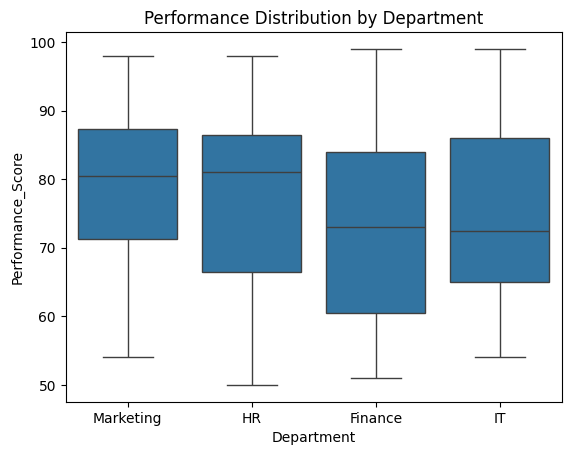

In [11]:
sns.boxplot(x="Department", y="Performance_Score", data=df)
plt.title("Performance Distribution by Department")
plt.show()

In [12]:
top10.to_csv("../Dataset/top_interns.csv", index=False)

Departments show different performance levels
High attendance leads to better performance
Completion rate directly impacts performance
Top interns have consistently high scores
Some interns need improvement

Day -3 (KPI Analysis)

In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("../Dataset/intern_data_cleaned.csv")
df.head()

,Intern_ID,Name,Department,Tasks_Assigned,Tasks_Completed,Hours_Worked,Attendance,Performance_Score,Completion_Rate
0,1,Meena,Marketing,19,8,174,93,92,42.105263
1,2,Sneha,HR,11,6,133,88,86,54.545455
2,3,Arjun,HR,5,13,137,97,61,100.000000
3,4,Meena,Finance,8,19,146,95,52,100.000000
4,5,Rahul,HR,17,8,183,92,50,47.058824


In [3]:
df["Completion_Rate"] = (df["Tasks_Completed"] / df["Tasks_Assigned"]) * 100

In [4]:
total_tasks = df["Tasks_Assigned"].sum()
completed_tasks = df["Tasks_Completed"].sum()
avg_completion = df["Completion_Rate"].mean()
avg_performance = df["Performance_Score"].mean()
avg_attendance = df["Attendance"].mean()

print("Total Tasks:", total_tasks)
print("Completed Tasks:", completed_tasks)
print("Avg Completion Rate:", avg_completion)
print("Avg Performance:", avg_performance)
print("Avg Attendance:", avg_attendance)

Total Tasks: 1183
Completed Tasks: 1011
Avg Completion Rate: 104.11341447510176
Avg Performance: 75.94
Avg Attendance: 85.89


In [5]:
dept_kpi = df.groupby("Department")[[
    "Completion_Rate",
    "Performance_Score",
    "Attendance"
]].mean()

print(dept_kpi)

            Completion_Rate  Performance_Score  Attendance
Department                                                
Finance          107.016844          72.541667   87.208333
HR               104.913413          76.850000   88.350000
IT                81.783617          75.346154   82.307692
Marketing        120.609829          78.566667   86.300000


In [6]:
best_dept = dept_kpi["Performance_Score"].idxmax()
print("Best Department:", best_dept)

Best Department: Marketing


<Axes: xlabel='Department'>

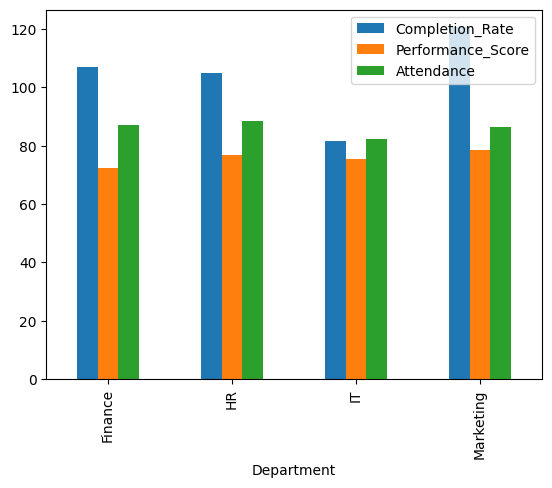

In [7]:
dept_kpi.plot(kind="bar")

Insights

Completion Rate is a key KPI for performance
Higher attendance leads to better performance
Some departments outperform others
Overall performance is influenced by task completion

Day -4 Dashboard Planning

## KPIs
- Completion Rate
- Performance Score
- Attendance

## Visualizations
- Bar Chart (Department Performance)
- Scatter Plot (Tasks Assigned vs Completed)
- Histogram (Attendance Distribution)
- Heatmap (Correlation)

## Dashboard Layout

Top Section:
- KPI Cards (Completion Rate, Performance, Attendance)

Middle Section:
- Bar Chart
- Scatter Plot

Bottom Section:
- Insights and Observations

## Purpose

The dashboard will help track intern performance, compare departments, and provide quick insights using KPIs and visualizations.

## Expected Insights
- Identify top performing interns
- Compare department performance
- Understand impact of attendance on performance